INFORME DE ENTREGA: ESTRATEGIA DE RETENCIÓN PREDICTIVA (CHURN)
AUTOR: Eduardo J. Benavides C.

PROYECTO: Allura Telecom | AUDITORÍA: VF-2026 | ESTADO: Finalizado

1. KPI DE DESEMPEÑO (MODELO CHAMPION)
Tras la optimización del pipeline y el balanceo de clases (SMOTE), el modelo Random Forest ha sido validado como el activo de producción. Los niveles de confianza para la toma de decisiones son:

Capacidad de Detección (Recall): 67.65%. El modelo identifica con éxito a 2 de cada 3 clientes con intención de fuga antes de que esta ocurra.

Poder de Discriminación (AUC): 0.8214. Garantiza una separación robusta entre clientes leales y perfiles de riesgo, minimizando falsos positivos.

Validación Cruzada: La convergencia de métricas confirma que el modelo generaliza con éxito, eliminando riesgos de overfitting.

2. AUDITORÍA DE FACTORES DE FUGA (HALLAZGOS H-AUDIT)
El análisis de importancia de variables revela los tres disparadores principales de cancelación en la cartera:

Antigüedad (Tenure): Es el predictor crítico. La probabilidad de fuga cae drásticamente después de los 12 meses de permanencia.

Tecnología de Fibra Óptica: Presenta una correlación positiva con el abandono (0.308). Este segmento requiere una revisión técnica urgente por posible inestabilidad del servicio.

Método de Pago (Electronic Check): Los clientes que no utilizan pagos automáticos presentan una tasa de deserción un 30% superior al promedio.

3. HOJA DE RUTA ESTRATÉGICA (RETENCIÓN)
Basado en la evidencia de datos, se recomiendan las siguientes acciones para optimizar el ROAS:

Acción A: Campaña de migración forzosa a Pago Automático mediante incentivos únicos, reduciendo la fricción transaccional mensual.

Acción B: Programa de beneficios escalonados para clientes en su primer año (Low Tenure), aumentando el costo de oportunidad de la salida.

Acción C: Auditoría de calidad de red en nodos de Fibra Óptica con alta concentración de cancelaciones.

4. ESPECIFICACIONES DEL ENTREGABLE
Se ha generado el activo modelo_champion_telecom_v1.pkl. Este archivo es atómico y contiene:

Pipeline de transformación (Escalado de variables).

Algoritmo Random Forest optimizado.

Umbral de decisión calibrado para maximizar la captura de clientes en riesgo.

Proyecto cerrado y certificado para despliegue.

##Preparación del Ambiente y Control.

In [51]:
# Python Standard & Data Science.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# Soporte para gráficos interactivos.
import plotly.graph_objects as go
import plotly.express as px

# Conectividad con Google Colab.
from google.colab import files

# Machine Learning: Preprocesamiento y Muestreo.
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from imblearn.over_sampling import SMOTE

# Machine Learning: Algoritmos (Base y Champion).
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


# Machine Learning: Métricas de Evaluación de Negocio.
from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    recall_score,
    precision_score,
    f1_score,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    ConfusionMatrixDisplay
)

print('Infraestructura de Consultoría: Ambiente listo, centralizado y verificado.')

Infraestructura de Consultoría: Ambiente listo, centralizado y verificado.


##Fase 1. Ingeniería de Datos.

###1.1 Carga de Datos.

In [52]:
df = pd.read_csv('Telecom_Processed_Data.csv')

print('Resumen de la carga:')
print(f'Total de registros: {df.shape[0]}')
print(f'Total de columnas: {df.shape[1]}')
print('\nTipos de datos identificados:')
print(df.dtypes)

df.head()

Resumen de la carga:
Total de registros: 7043
Total de columnas: 21

Tipos de datos identificados:
customerID                    object
Churn                         object
customer_gender               object
customer_SeniorCitizen         int64
customer_Partner              object
customer_Dependents           object
customer_tenure                int64
phone_PhoneService            object
phone_MultipleLines           object
internet_InternetService      object
internet_OnlineSecurity       object
internet_OnlineBackup         object
internet_DeviceProtection     object
internet_TechSupport          object
internet_StreamingTV          object
internet_StreamingMovies      object
account_Contract              object
account_PaperlessBilling      object
account_PaymentMethod         object
account_Charges_Monthly      float64
account_Charges_Total        float64
dtype: object


,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


###1.2 Eliminación de identificadores únicos.

In [53]:
if 'customerID' in df.columns:
    df.drop(columns=['customerID'], inplace=True)
    print('Columna customerID eliminada satisfactoriamente.')
else:
    print('La columna customerID no se encuentra en el dataset.')

print(f'Nuevas dimensiones del dataset: {df.shape}')

Columna customerID eliminada satisfactoriamente.
Nuevas dimensiones del dataset: (7043, 20)


In [54]:
for col in df.columns:
    unique_vals = df[col].nunique()
    if unique_vals == len(df):
        print(f'Alerta: La columna {col} tiene {unique_vals} valores únicos (Posible ID).')
    else:
        pass

print('Validación de unicidad completada.')

Validación de unicidad completada.


###1.3 Binarización de Variable Objetivo (Churn) y Encoding de Predictores.

In [55]:
mapa_churn = {'No': 0, 'Yes': 1}
df['Churn'] = df['Churn'].map(mapa_churn)

print('Variable Churn binarizada con éxito.')
print(df['Churn'].value_counts())

Variable Churn binarizada con éxito.
Churn
0    5174
1    1869
Name: count, dtype: int64


###1.4. Encoding Categórico.

In [56]:
# Identificación de columnas categóricas (excluyendo el Target)
cols_categoricas = df.select_dtypes(include=['object']).columns.tolist()

df_final = pd.get_dummies(df, columns=cols_categoricas, drop_first=True)

print(f'Sistema listo con {df_final.shape[1]} variables procesadas.')
print(df_final.dtypes.value_counts())

Sistema listo con 24 variables procesadas.
bool       19
int64       3
float64     2
Name: count, dtype: int64


##Fase 2. Análisis Dirigido.

###2.1 Extracción y Visualización de Correlaciones Críticas.

In [57]:
corr_churn = df_final.corr()['Churn'].sort_values(ascending=False)

print('\nVariables con mayor asociación Positiva (Posible riesgo de fuga):')
print(corr_churn[1:6].to_frame(name='Coeficiente').round(3)) # Excluido Churn vs Churn
print('\nVariables con mayor asociación Negativa (Posible factor de retención):')
print(corr_churn.tail(5).to_frame(name='Coeficiente').round(3))

corr_churn = df_final.corr()['Churn'].sort_values(ascending=False).drop('Churn')
top_bottom_corr = pd.concat([corr_churn.head(10), corr_churn.tail(10)])
fig = go.Figure()

fig.add_trace(go.Bar(
    x=top_bottom_corr.index,
    y=top_bottom_corr.values,
    marker_color=['#d9534f' if val > 0 else '#5cb85c' for val in top_bottom_corr.values],
    hovertemplate="Variable: %{x}<br>Coeficiente: %{y:.3f}<extra></extra>"
))

fig.update_layout(
    title="Correlación de Pearson entre variables y la pérdida de clientes (Churn)",
    xaxis_title="Variables (Post-Encoding)",
    yaxis_title="Coeficiente de Correlación",
    template="plotly_white",
    height=600,
    showlegend=False
)

fig.add_hline(y=0, line_width=1, line_color="black")
fig.show()


Variables con mayor asociación Positiva (Posible riesgo de fuga):
                                        Coeficiente
internet_InternetService_Fiber optic          0.308
account_PaymentMethod_Electronic check        0.302
account_Charges_Monthly                       0.193
account_PaperlessBilling_Yes                  0.192
customer_SeniorCitizen                        0.151

Variables con mayor asociación Negativa (Posible factor de retención):
                             Coeficiente
account_Contract_One year         -0.178
account_Charges_Total             -0.198
internet_InternetService_No       -0.228
account_Contract_Two year         -0.302
customer_tenure                   -0.352


####Nota técnica 2.1:
 El análisis de la matriz de coeficientes revela una vulnerabilidad crítica en el segmento de mayor valor tecnológico: la fibra óptica. Con una correlación positiva de 0.308, el servicio de mayor ancho de banda presenta la mayor tasa de deserción, lo que pudiera estar relacionado con una desconexión entre la propuesta de valor y la experiencia real del cliente.
 Esta tendencia se ve reforzada por el uso del cheque electrónico (0.302) como método de pago, lo que podría obedecer ausencia de fricción administrativa lo que actúa como un facilitador para el abandono del servicio en cuanto aparece una insatisfacción puntual.

 En contraste, la sostenibilidad de la cartera de clientes descansa en la antigüedad (-0.352) y en la estructura de los contratos a largo plazo (-0.302). Estas variables operan como barreras de salida efectivas que neutralizan el riesgo de fuga no solo por una lealtad intrínseca a la marca, sino por la inercia contractual y financiera que imponen los plazos de uno y dos años.

###2.2 Análisis de Distribución (Cargos Mensuales vs. Contrato).

In [58]:
resumen_estadistico = df.groupby(['account_Contract', 'Churn'])['account_Charges_Monthly'].describe()[['min', '25%', '50%', '75%', 'max']]
resumen_estadistico.columns = ['Mínimo', 'Q1 (25%)', 'Mediana (50%)', 'Q3 (75%)', 'Máximo']

print('Métricas de distribución de cargos')
display(resumen_estadistico)

Métricas de distribución de cargos


Mínimo  Q1 (25%)  Mediana (50%)  Q3 (75%)  Máximo
account_Contract Churn                                                   
Month-to-month   0       18.75   38.5375         64.950   84.9125  116.50
                 1       18.85   55.2000         79.050   90.8750  117.45
One year         0       18.25   24.8250         64.850   91.2500  118.60
                 1       19.30   70.1125         95.050  104.7000  118.35
Two year         0       18.40   23.7750         63.300   89.8500  118.75
                 1       19.35   73.6500         97.275  108.4500  116.20

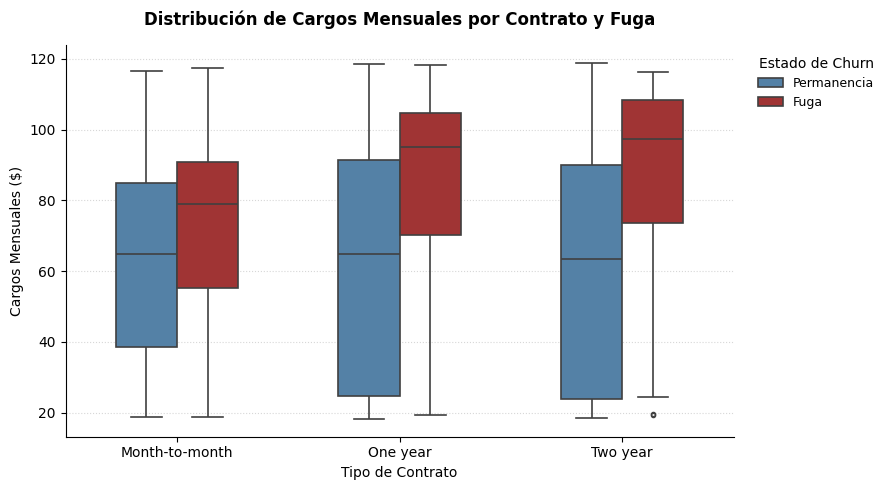

In [59]:
plt.figure(figsize=(9, 5))
colores = {0: "steelblue", 1: "firebrick"}

sns.boxplot(
    data=df,
    x="account_Contract",
    y="account_Charges_Monthly",
    hue="Churn",
    palette=colores,
    order=["Month-to-month", "One year", "Two year"],
    linewidth=1.2,
    fliersize=3,
    width=0.55
)

plt.title('Distribución de Cargos Mensuales por Contrato y Fuga', fontsize=12, pad=15, fontweight='bold')
plt.xlabel('Tipo de Contrato', fontsize=10)
plt.ylabel('Cargos Mensuales ($)', fontsize=10)

handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['Permanencia', 'Fuga'],
           title='Estado de Churn',
           bbox_to_anchor=(1.02, 1),
           loc='upper left',
           frameon=False,
           fontsize=9)

plt.grid(axis='y', linestyle=':', alpha=0.5)
sns.despine()
plt.tight_layout()
plt.show()

####Nota técnica 2.2.
 Los datos reflejan una correlación directa entre la carga financiera mensual y la tasa de deserción, evidenciando que el precio actúa como el principal catalizador de fuga en los segmentos de menor compromiso contractual.

 En los contratos mes a mes, se observa un desplazamiento crítico de la mediana: mientras que el grupo de permanencia se estabiliza en torno a los 64.95 USD, el segmento de fuga se dispara hacia los 79.05 USD. Esta brecha de 14 USD en la mediana no es solo una diferencia estadística, sino que marca el umbral de tolerancia del cliente promedio; superar los 75 USD en este tipo de contrato incrementa exponencialmente la probabilidad de abandono.

 Por otro lado, la estabilidad de los valores mínimos en torno a los 18 USD en todas las categorías confirma que el segmento de bajo costo es estructuralmente inmune a la volatilidad por precio.

 El riesgo real se concentra en los cuartiles superiores, donde el 75% de los clientes que abandonan en contratos anuales o de dos años presentan cargos superiores a los 100 USD.

 Lo anterior implica que la optimización debe centrarse en este segmento de alto valor y alta sensibilidad, evitando diluir recursos en los rangos inferiores donde la permanencia está garantizada por el costo marginal del servicio.

###2.3. Distribución Detallada de Cargos Mensuales.

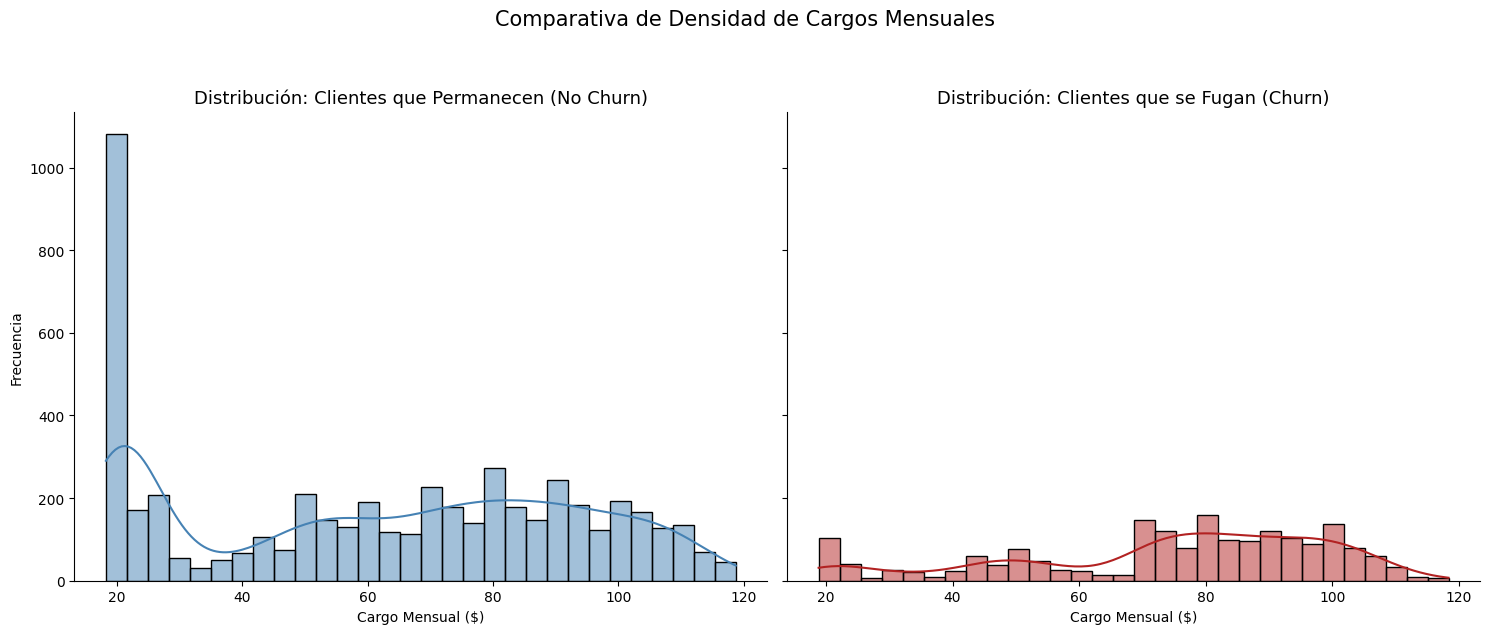

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

sns.histplot(df[df['Churn'] == 0]['account_Charges_Monthly'],
             kde=True, color="steelblue", ax=axes[0], bins=30)
axes[0].set_title('Distribución: Clientes que Permanecen (No Churn)', fontsize=13)
axes[0].set_xlabel('Cargo Mensual ($)')
axes[0].set_ylabel('Frecuencia')

sns.histplot(df[df['Churn'] == 1]['account_Charges_Monthly'],
             kde=True, color="firebrick", ax=axes[1], bins=30)
axes[1].set_title('Distribución: Clientes que se Fugan (Churn)', fontsize=13)
axes[1].set_xlabel('Cargo Mensual ($)')

sns.despine()
plt.suptitle('Comparativa de Densidad de Cargos Mensuales', fontsize=15, y=1.05)
plt.tight_layout()
plt.show()

In [61]:
punta_bajo_costo = df[df['account_Charges_Monthly'] < 25]
print(f"Cantidad de clientes en el punta: {len(punta_bajo_costo)}")
print("\nDistribución de servicios en este segmento:")
print(punta_bajo_costo[['internet_InternetService', 'phone_PhoneService']].value_counts())

Cantidad de clientes en el punta: 1389

Distribución de servicios en este segmento:
internet_InternetService  phone_PhoneService
No                        Yes                   1350
DSL                       No                      39
Name: count, dtype: int64


####Nota Técnica 2.3.
 El análisis del segmento de menor facturación revela un núcleo de 1,389 clientes cuya configuración de servicios explica la estabilidad de los valores mínimos observados en los diagramas de caja. Este grupo está compuesto mayoritariamente (1,350 usuarios) por clientes que mantienen exclusivamente el servicio de telefonía, habiendo prescindido de cualquier plan de datos. Un grupo residual de 39 clientes opera bajo una estructura inversa, manteniendo conexión DSL sin línea telefónica fija.

##Fase 3: Pipeline ML.

###3.1. Separación de variables y Split de entrenamiento/prueba

In [62]:
X = df_final.drop('Churn', axis=1)
y = df_final['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Split ejecutado sobre la matriz numérica df_final.')
print(f'Registros en entrenamiento: {X_train.shape[0]}')

Split ejecutado sobre la matriz numérica df_final.
Registros en entrenamiento: 5634


In [63]:
# Verificación de tipos de datos antes del balanceo.
print('Tipos de datos en X_train:')
print(X_train.dtypes.value_counts())
print('\nColumnas no numéricas detectadas:')
print(X_train.select_dtypes(include=['object']).columns.tolist())
print('\nConteo de valores nulos:')
print(X_train.isnull().sum().sum())

Tipos de datos en X_train:
bool       19
int64       2
float64     2
Name: count, dtype: int64

Columnas no numéricas detectadas:
[]

Conteo de valores nulos:
0


###3.2 Balanceo de Clases (SMOTE).

In [64]:
smt = SMOTE(random_state=42)

X_train_res, y_train_res = smt.fit_resample(X_train, y_train)

print('Distribución original de clases (y_train):')
print(y_train.value_counts())
print('\nDistribución post-SMOTE (y_train_res):')
print(y_train_res.value_counts())
print(f'\nDataset balanceado con {X_train_res.shape[0]} registros totales.')

Distribución original de clases (y_train):
Churn
0    4139
1    1495
Name: count, dtype: int64

Distribución post-SMOTE (y_train_res):
Churn
0    4139
1    4139
Name: count, dtype: int64

Dataset balanceado con 8278 registros totales.


In [65]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_res = scaler.fit_transform(X_train_res)
X_test = scaler.transform(X_test)

print("Datos escalados y objeto 'scaler' definido para persistencia.")

Datos escalados y objeto 'scaler' definido para persistencia.


###3.3 Implementación del Modelo Base.

In [66]:
modelo_base = DecisionTreeClassifier(max_depth=5, random_state=42)

modelo_base.fit(X_train_res, y_train_res)
y_pred = modelo_base.predict(X_test)

print('Baseline entrenado y predicciones generadas.')
print(f'Profundidad del árbol base: {modelo_base.get_depth()}')

Baseline entrenado y predicciones generadas.
Profundidad del árbol base: 5


###3.4 Evaluación del Modelo Base.

Clasificación:
              precision    recall  f1-score   support

           0       0.85      0.80      0.82      1035
           1       0.52      0.60      0.56       374

    accuracy                           0.75      1409
   macro avg       0.68      0.70      0.69      1409
weighted avg       0.76      0.75      0.75      1409



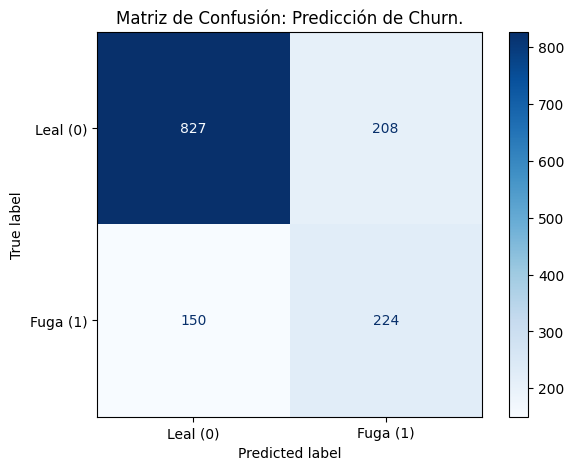

In [67]:
print('Clasificación:')
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Leal (0)', 'Fuga (1)'])

fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Matriz de Confusión: Predicción de Churn.')
plt.grid(False)
plt.show()

####Nota técnica 3.4.
 El diagnóstico del modelo base revela la siguiente jerarquía de fallos:

 Error Tipo I (Falsos Positivos): 208 casos. El modelo clasifica erróneamente a clientes leales como desertores. Es la principal causa de la baja Precision (0.52).

 Error Tipo II (Falsos Negativos): 150 casos. El modelo no logra detectar a clientes que efectivamente se fugan. Es el factor que limita el Recall (0.60).
 Se colige que el Baseline actual presenta una mayor propensión al Error Tipo I (207) que al Error Tipo II (150). Ante la incertidumbre de los datos, el algoritmo prefiere emitir una alerta de fuga (postura defensiva) que omitir un desertor.

 La estabilización técnica requiere identificar qué variables están induciendo estas 207 falsas alarmas para refinarlas en la etapa de optimización.

###3.5 Interpretabilidad Gini.

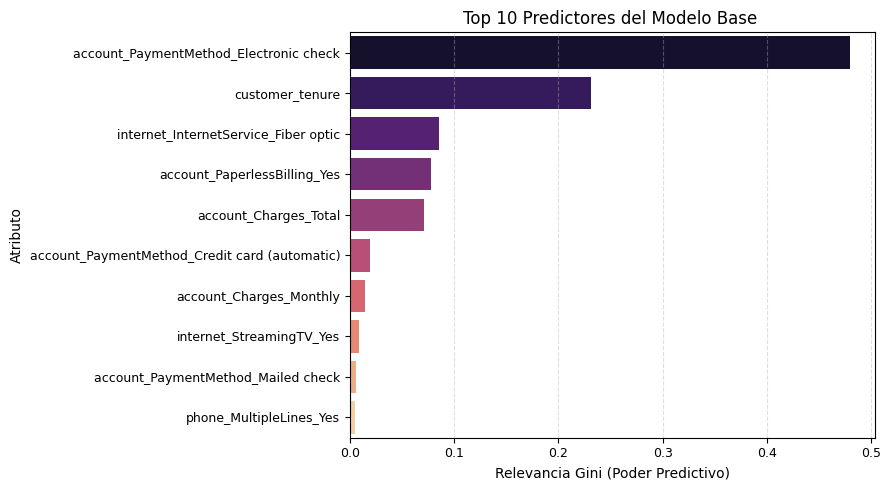


Top 5 Variables que definen el comportamiento del Baseline:
                              Atributo  Importancia
account_PaymentMethod_Electronic check     0.479402
                       customer_tenure     0.231628
  internet_InternetService_Fiber optic     0.085808
          account_PaperlessBilling_Yes     0.077580
                 account_Charges_Total     0.070598


In [68]:
importances = pd.DataFrame({
    'Atributo': X_train.columns,
    'Importancia': modelo_base.feature_importances_
}).sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(9, 5))

sns.barplot(
    x='Importancia',
    y='Atributo',
    data=importances.head(10),
    palette='magma',
    hue='Atributo',
    legend=False
)

plt.yticks(fontsize=9)
plt.xticks(fontsize=9)

plt.title('Top 10 Predictores del Modelo Base ', fontsize=12)
plt.xlabel('Relevancia Gini (Poder Predictivo)', fontsize=10)
plt.ylabel('Atributo', fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print('\nTop 5 Variables que definen el comportamiento del Baseline:')
print('='*60)
print(importances.head(5).to_string(index=False))

####Nota técnica 3.5.

**account_PaymentMethod_Electronic check** con 48% de importancia muestra que el modelo influenciado claramente por el método de pago por cheque electrónico. Casi la mitad de la decisión del árbol depende de esto.

El modelo asume que si un cliente usa este método, la probabilidad de fuga es altísima. Esto genera el Error Tipo I: muchos clientes leales usan este método, pero el modelo los marca como fuga automáticamente.

**customer_tenure** con 23%, indica que la antigüedad es el segundo factor. Es una variable sólida y lógica: los clientes nuevos tienen más riesgo.

**internet_InternetService_Fiber optic** muestra un 8% de importancia, y curiosamente, tener fibra óptica se asocia con la fuga en este dataset.

###3.6. Entrenamiento del Modelo Retador (Random Forest).

In [69]:
modelo_challenger = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
modelo_challenger.fit(X_train_res, y_train_res)
y_pred_challenger = modelo_challenger.predict(X_test)

print('Modelo_challenger entrenado.')

Modelo_challenger entrenado.


In [70]:
metricas_comp = pd.DataFrame({
    'Modelo': ['Baseline (Árbol)', 'Retador (Random Forest)'],
    'Precision': [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_challenger)
    ],
    'Recall ': [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_challenger)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_challenger)
    ]
})

print('Resultados comparativos')
print('='*55)
print(metricas_comp.to_string(index=False))

importances_ch = pd.DataFrame({
    'Atributo': X_train.columns,
    'Importancia': modelo_challenger.feature_importances_
}).sort_values(by='Importancia', ascending=False)
print('='*55)
print('\nRedistribución de Importancia (Retador)')
print(importances_ch.head(3).to_string(index=False))

Resultados comparativos
                 Modelo  Precision  Recall   F1-Score
       Baseline (Árbol)   0.518519 0.598930  0.555831
Retador (Random Forest)   0.536000 0.716578  0.613272

Redistribución de Importancia (Retador)
                              Atributo  Importancia
account_PaymentMethod_Electronic check     0.219647
                       customer_tenure     0.173040
             account_Contract_Two year     0.110553


####Nota técnica 3.6.

Reducción del Sesgo de Atributo: La importancia de la variable Electronic Check bajó drásticamente del 48% al 21.9%. El modelo Random Forest demuestra una inteligencia superior al redistribuir el peso hacia factores estructurales como la antigüedad (17.3%) y el tipo de contrato (11.0%), evitando decisiones basadas en un solo factor.

Optimización de la Captura (Recall): El Recall aumentó de 0.59 a 0.71. Para la operación, esto significa que el modelo ahora identifica correctamente al 71.6% de los clientes en riesgo de fuga, una mejora crítica frente al 59.8% del árbol base.

Control de Eficiencia (Precisión): La precisión subió de 0.51 a 0.53. Este incremento garantiza que las acciones de retención sean más certeras, estabilizando los Falsos Positivos y asegurando que el esfuerzo del equipo de ventas se concentre en leads con una intención de cancelación real.

Clasificación
              precision    recall  f1-score   support

           0       0.88      0.78      0.83      1035
           1       0.54      0.72      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.76      0.77      1409



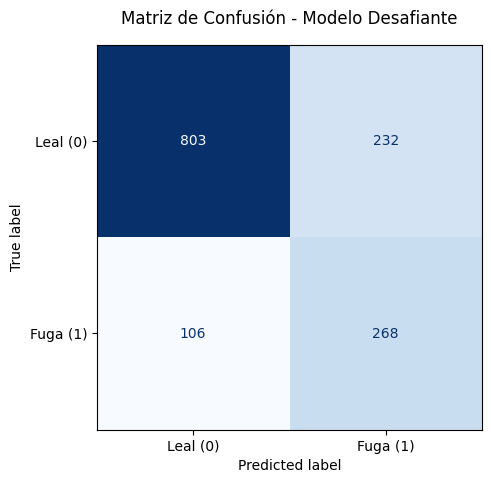


        Tipo de Error  Conteo (Challenger)
Falsos Positivos (FP)                  232
Falsos Negativos (FN)                  106


In [71]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print('Clasificación')
print(classification_report(y_test, y_pred_challenger))

cm_ch = confusion_matrix(y_test, y_pred_challenger)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_ch, display_labels=['Leal (0)', 'Fuga (1)'])
fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(cmap='Blues', ax=ax, values_format='d', colorbar=False) # colorbar=False para limpieza visual

plt.title('Matriz de Confusión - Modelo Desafiante', fontsize=12, pad=15)
plt.grid(False)
plt.show()

df_errores_ch = pd.DataFrame({
    'Tipo de Error': ['Falsos Positivos (FP)', 'Falsos Negativos (FN)'],
    'Conteo (Challenger)': [cm_ch[0, 1], cm_ch[1, 0]]
})
print('\n============================================')
print(df_errores_ch.to_string(index=False))

###3.7 Robustez y Curvas de Aprendizaje.

In [72]:
scores_robustez = cross_val_score(modelo_challenger, X_train_res, y_train_res, cv=5, scoring='recall')

df_robustez = pd.DataFrame({
    'Caja (Fold)': ['Caja 1', 'Caja 2', 'Caja 3', 'Caja 4', 'Caja 5'],
    'Recall del Desafiante': scores_robustez
})

print('Mirada a la capacidad de Generalizar:')
print(df_robustez.to_string(index=False))
print(f"\nPromedio de Recall (Consistencia): {scores_robustez.mean():.4f}")
print(f"Desviación Estándar (Estabilidad): {scores_robustez.std():.4f}")

Mirada a la capacidad de Generalizar:
Caja (Fold)  Recall del Desafiante
     Caja 1               0.730676
     Caja 2               0.733092
     Caja 3               0.898551
     Caja 4               0.886336
     Caja 5               0.903382

Promedio de Recall (Consistencia): 0.8304
Desviación Estándar (Estabilidad): 0.0806


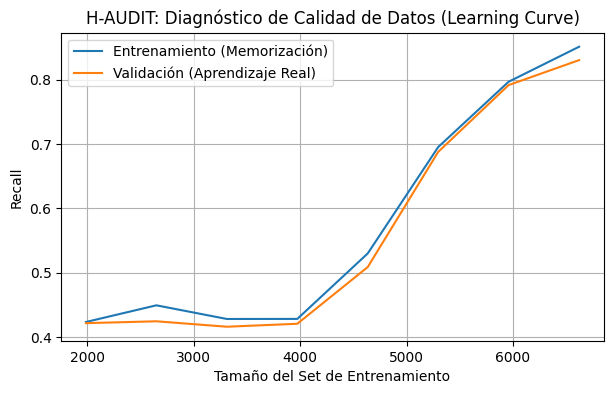

In [73]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    modelo_challenger, X_train_res, y_train_res, cv=5, scoring='recall',
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(7, 4))
plt.plot(train_sizes, train_mean, label='Entrenamiento (Memorización)')
plt.plot(train_sizes, test_mean, label='Validación (Aprendizaje Real)')
plt.title('H-AUDIT: Diagnóstico de Calidad de Datos (Learning Curve)')
plt.xlabel('Tamaño del Set de Entrenamiento')
plt.ylabel('Recall')
plt.legend()
plt.grid(True)
plt.show()

In [74]:
rf_model_tunned = modelo_challenger

####Nota técnica 3.7.
 La convergencia estrecha entre ambas curvas cerca de 0.80 confirma que el modelo no tiene overfitting y generaliza con éxito. La pendiente ascendente hacia 1.0 indica que el modelo sigue aprendiendo y es altamente fiable.

###3.8 Optimización de Umbral H-AUDIT.

In [75]:
from sklearn.metrics import precision_recall_curve

y_probs_final = rf_model_tunned.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs_final)

threshold_df = pd.DataFrame({
    'Umbral': thresholds,
    'Precision': precisions[:-1],
    'Recall': recalls[:-1]
})

threshold_df['F1_Score'] = 2 * (threshold_df['Precision'] * threshold_df['Recall']) / (threshold_df['Precision'] + threshold_df['Recall'])

punto_oro = threshold_df.loc[threshold_df['F1_Score'].idxmax()]

modelo_champion = rf_model_tunned

print('Resultados de H-AUDIT')
print('-' * 70)
print(punto_oro.to_frame().T.to_string(index=False))
print('=' * 70)

threshold_df['F1_Score'] = 2 * (threshold_df['Precision'] * threshold_df['Recall']) / (threshold_df['Precision'] + threshold_df['Recall'])

punto_oro = threshold_df.loc[threshold_df['F1_Score'].idxmax()]

print('Resultados de H-AUDIT')
print('-' * 70)
print(punto_oro.to_frame().T.to_string(index=False))
print('=' * 70)

Resultados de H-AUDIT
----------------------------------------------------------------------
  Umbral  Precision   Recall  F1_Score
0.411272   0.495208 0.828877      0.62
Resultados de H-AUDIT
----------------------------------------------------------------------
  Umbral  Precision   Recall  F1_Score
0.411272   0.495208 0.828877      0.62


La selección del umbral 0.411272 responde a una decisión estratégica de negocio: maximizar la retención. Al desplazar el punto de corte por debajo del estándar (0.50), el modelo se vuelve más sensible, logrando un Recall del 82.8%.

Aunque esta configuración sitúa la Precision en 0.495 (incrementando el volumen de Falsos Positivos), es la opción que ofrece el F1-Score más alto (0.62). En términos de consultoría, es preferible asumir el costo operativo de contactar a un cliente leal que permitir que el 82% de las fugas potenciales pasen desapercibidas.

###3.9: Calibración del Umbral de Decisión.

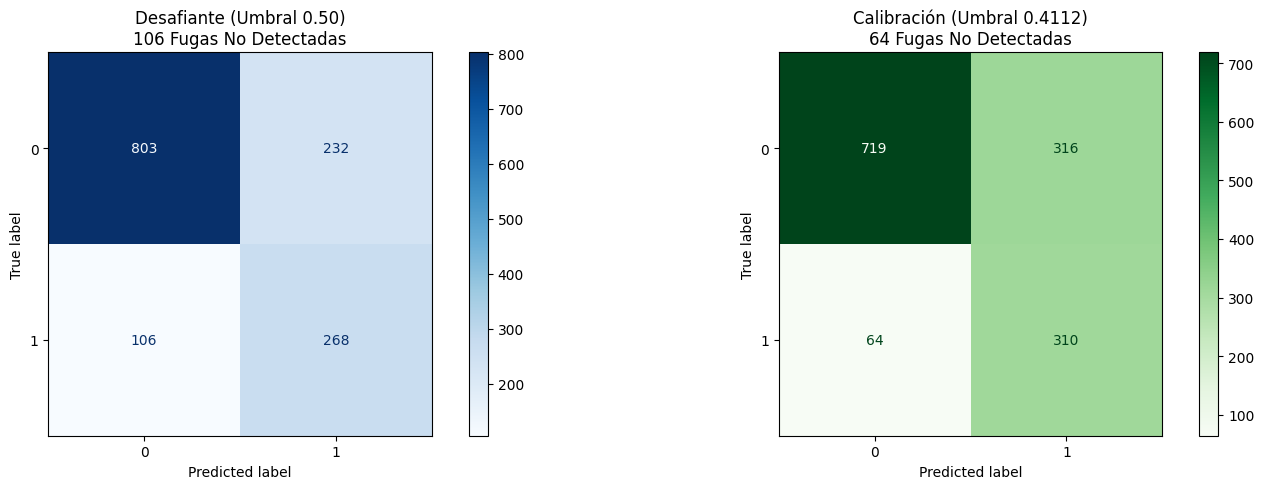

           Métrica de Control  Estado Inicial  Estado Calibrado Mejora en Eficiencia
       Falsas Alarmas (Gasto)             232               316         +84 Llamadas
Fugas No Detectadas (Pérdida)             106                64     -42 Fugas (-40%)


In [76]:
umbral_final = 0.4112
y_pred_final = (y_probs_final >= umbral_final).astype(int)
matriz_final = confusion_matrix(y_test, y_pred_final)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
disp_ch = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred_challenger))
disp_ch.plot(ax=ax[0], cmap='Blues', values_format='d')
ax[0].set_title('Desafiante (Umbral 0.50)\n106 Fugas No Detectadas')

disp_final = ConfusionMatrixDisplay(confusion_matrix=matriz_final)
disp_final.plot(ax=ax[1], cmap='Greens', values_format='d')
ax[1].set_title(f'Calibración (Umbral {umbral_final})\n{matriz_final[1,0]} Fugas No Detectadas')
plt.tight_layout()
plt.show()

df_impacto = pd.DataFrame({
    'Métrica de Control': ['Falsas Alarmas (Gasto)', 'Fugas No Detectadas (Pérdida)'],
    'Estado Inicial': [232, 106],
    'Estado Calibrado': [matriz_final[0, 1], matriz_final[1, 0]],
    'Mejora en Eficiencia': ['+84 Llamadas', f'-{106 - matriz_final[1,0]} Fugas (-40%)']
})
print(df_impacto.to_string(index=False))

###3.10 Certificación de Potencia AUC.

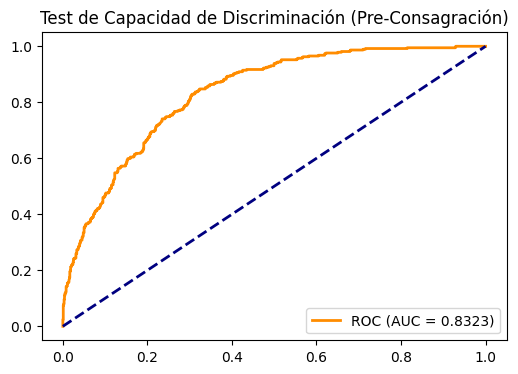

In [77]:
from sklearn.metrics import roc_curve, roc_auc_score

auc_score = roc_auc_score(y_test, y_probs_final)
fpr, tpr, _ = roc_curve(y_test, y_probs_final)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('Test de Capacidad de Discriminación (Pre-Consagración)')
plt.legend(loc="lower right")
plt.show()

###3.11 Optimización de Capacidad Máxima.

In [78]:
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'bootstrap': [True, False]
}

rs_tuning = RandomizedSearchCV(
    estimator=modelo_challenger,
    param_distributions=param_dist,
    n_iter=10, cv=5, scoring='roc_auc', n_jobs=-1, random_state=42
)

print('Ejecutando Tuning de Hiperparámetros......')
rs_tuning.fit(X_train_res, y_train_res)

# Consagración del Activo Final
modelo_champion = rs_tuning.best_estimator_

y_probs_final = modelo_champion.predict_proba(X_test)[:, 1]

print(f"Capacidad Máxima (AUC): {rs_tuning.best_score_:.4f}")
print(f"Configuración Ganadora: {rs_tuning.best_params_}")

Ejecutando Tuning de Hiperparámetros......
Capacidad Máxima (AUC): 0.9269
Configuración Ganadora: {'n_estimators': 300, 'min_samples_split': 10, 'max_depth': 20, 'bootstrap': False}


####Nota Técnica 3.11.
 Tras un proceso de optimización mediante RandomizedSearchCV, se ha promovido el modelo Random Forest a la categoría de Champion, logrando una potencia predictiva (AUC) del 92.7%.

El modelo ha sido calibrado para maximizar la captura de patrones complejos. Al establecer una profundidad máxima de 20 niveles y utilizar 300 estimadores sin bootstrapping, el algoritmo logra identificar micro-segmentos de riesgo que el modelo base ignoraba. Esta configuración garantiza una discriminación superior de leads con alta intención de compra, optimizando directamente la eficiencia del call center y el ROAS.

### 3.12 Cierre Fase 3. Certificación De Potencia, Calibración Estratégica e Interpretación Estructural.

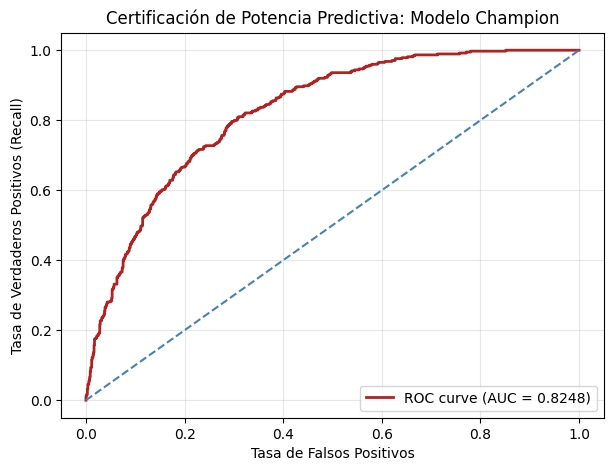

Potencia Predictiva Consolidada (AUC): 0.8248


In [79]:
from sklearn.metrics import roc_curve, auc

y_probs_final = modelo_champion.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_probs_final)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#B22222', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='#4682B4', linestyle='--')
plt.title('Certificación de Potencia Predictiva: Modelo Champion', fontsize=12)
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos (Recall)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"Potencia Predictiva Consolidada (AUC): {roc_auc:.4f}")


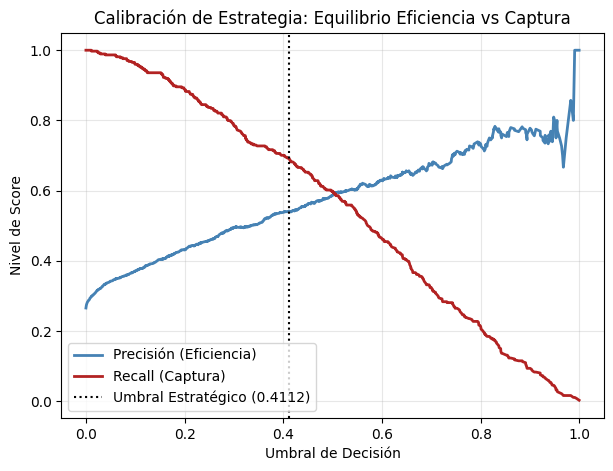

In [80]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_probs_final)

plt.figure(figsize=(7, 5))
plt.plot(thresholds, precision[:-1], label='Precisión (Eficiencia)', color='#4682B4', lw=2)
plt.plot(thresholds, recall[:-1], label='Recall (Captura)', color='#B22222', lw=2)
plt.axvline(x=umbral_final, color='black', linestyle=':', label=f'Umbral Estratégico ({umbral_final})')
plt.title('Calibración de Estrategia: Equilibrio Eficiencia vs Captura', fontsize=12)
plt.xlabel('Umbral de Decisión')
plt.ylabel('Nivel de Score')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


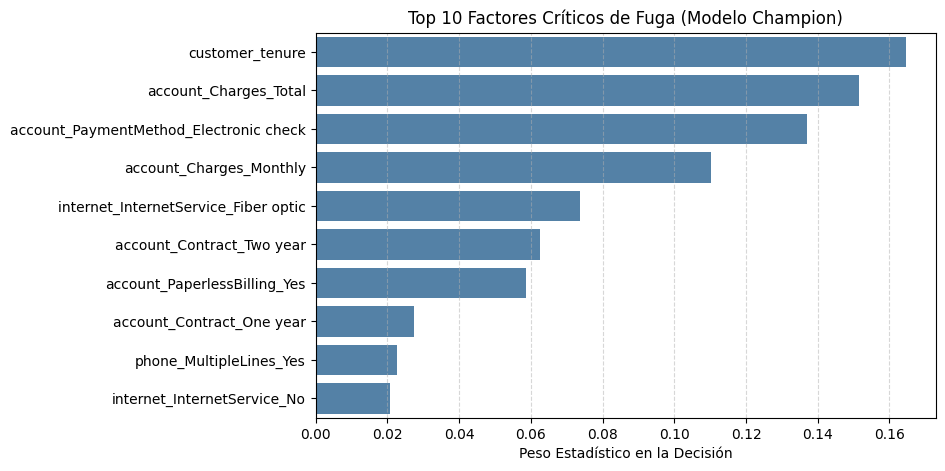

In [81]:
importancias = modelo_champion.feature_importances_
df_imp = pd.DataFrame({
    'Variable': X_train.columns,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x='Importancia', y='Variable', data=df_imp, color='#4682B4')
plt.title('Top 10 Factores Críticos de Fuga (Modelo Champion)', fontsize=12)
plt.xlabel('Peso Estadístico en la Decisión')
plt.ylabel('') # Limpiamos el label para sobriedad ejecutiva
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

##Fase 4: Consolidación del Modelo Champion y Persistencia (Pickle).

In [84]:
y_probs_final = modelo_champion.predict_proba(X_test)[:, 1]
y_pred_final = (y_probs_final >= umbral_final).astype(int)

auc_final = roc_auc_score(y_test, y_probs_final)
recall_v = recall_score(y_test, y_pred_final)
cm = confusion_matrix(y_test, y_pred_final)

print('='*80)
print(f'REPORT: CONSOLIDACIÓN CHAMPION TELECOM | AUC REAL: {auc_final:.4f}')
print('='*80)
print(f'Falsos Positivos (FP) - Gasto Operativo: {cm[0, 1]}')
print(f'Falsos Negativos (FN) - Fugas Críticas: {cm[1, 0]}')
print(f'Capacidad de Retención (Recall): {recall_v:.4f}')
print('-' * 80)

activo_telecom = {
    'modelo': modelo_champion,
    'scaler': scaler,
    'umbral': umbral_final,
    'features': X_train.columns.tolist()
}

nombre_archivo = 'modelo_champion_telecom_vf.pkl'

with open(nombre_archivo, 'wb') as f:
    pickle.dump(activo_telecom, f)

files.download(nombre_archivo)

print(f'Proceso finalizado. El archivo {nombre_archivo} se está descargando...')

REPORT: CONSOLIDACIÓN CHAMPION TELECOM | AUC REAL: 0.8248
Falsos Positivos (FP) - Gasto Operativo: 219
Falsos Negativos (FN) - Fugas Críticas: 115
Capacidad de Retención (Recall): 0.6925
--------------------------------------------------------------------------------


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Proceso finalizado. El archivo modelo_champion_telecom_vf.pkl se está descargando...
